<a href="https://colab.research.google.com/github/minfa496-spec/regression-project/blob/main/HR_Analytics_job_prediction_regression_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_absolute_percentage_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import root_mean_squared_error
import matplotlib.pyplot as plt
df=pd.read_csv("/content/HR_comma_sep.csv")
df

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low
...,...,...,...,...,...,...,...,...,...,...
14994,0.40,0.57,2,151,3,0,1,0,support,low
14995,0.37,0.48,2,160,3,0,1,0,support,low
14996,0.37,0.53,2,143,3,0,1,0,support,low
14997,0.11,0.96,6,280,4,0,1,0,support,low


In [ ]:
df.head()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low


In [ ]:
df.tail()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department,salary
14994,0.40,0.57,2,151,3,0,1,0,support,low
14995,0.37,0.48,2,160,3,0,1,0,support,low
14996,0.37,0.53,2,143,3,0,1,0,support,low
14997,0.11,0.96,6,280,4,0,1,0,support,low
14998,0.37,0.52,2,158,3,0,1,0,support,low


In [ ]:
df.describe()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years
count,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000
mean,0.612834,0.716102,3.803054,201.050337,3.498233,0.144610,0.238083,0.021268
std,0.248631,0.171169,1.232592,49.943099,1.460136,0.351719,0.425924,0.144281
min,0.090000,0.360000,2.000000,96.000000,2.000000,0.000000,0.000000,0.000000
25%,0.440000,0.560000,3.000000,156.000000,3.000000,0.000000,0.000000,0.000000
50%,0.640000,0.720000,4.000000,200.000000,3.000000,0.000000,0.000000,0.000000
75%,0.820000,0.870000,5.000000,245.000000,4.000000,0.000000,0.000000,0.000000
max,1.000000,1.000000,7.000000,310.000000,10.000000,1.000000,1.000000,1.000000


In [ ]:
df.dtypes

,0
satisfaction_level,float64
last_evaluation,float64
number_project,int64
average_montly_hours,int64
time_spend_company,int64
Work_accident,int64
left,int64
promotion_last_5years,int64
Department,object
salary,object


In [ ]:
df.columns

Index(['satisfaction_level', 'last_evaluation', 'number_project',
       'average_montly_hours', 'time_spend_company', 'Work_accident', 'left',
       'promotion_last_5years', 'Department', 'salary'],
      dtype='object')

In [ ]:
df.isna().sum()

,0
satisfaction_level,0
last_evaluation,0
number_project,0
average_montly_hours,0
time_spend_company,0
Work_accident,0
left,0
promotion_last_5years,0
Department,0
salary,0


In [ ]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
df["Department"]=le.fit_transform(df['Department'])
df['Department']

,Department
0,7
1,7
2,7
3,7
4,7
...,...
14994,8
14995,8
14996,8
14997,8


In [ ]:
df["salary"]=le.fit_transform(df["salary"])
df["salary"]

,salary
0,1
1,2
2,2
3,1
4,1
...,...
14994,1
14995,1
14996,1
14997,1


In [ ]:
df["satisfaction_level"]=le.fit_transform(df["satisfaction_level"])
df["satisfaction_level"]

,satisfaction_level
0,29
1,71
2,2
3,63
4,28
...,...
14994,31
14995,28
14996,28
14997,2


In [ ]:
df["last_evaluation"]=le.fit_transform(df["last_evaluation"])
df["last_evaluation"]

,last_evaluation
0,17
1,50
2,52
3,51
4,16
...,...
14994,21
14995,12
14996,17
14997,60


In [ ]:
features=list(zip(df["Department"],df["salary"],df["satisfaction_level"],df["last_evaluation"]))
features

[(7, 1, 29, 17),
 (7, 2, 71, 50),
 (7, 2, 2, 52),
 (7, 1, 63, 51),
 (7, 1, 28, 16),
 (7, 1, 32, 14),
 (7, 1, 1, 41),
 (7, 1, 83, 49),
 (7, 1, 80, 64),
 (7, 1, 33, 17),
 (7, 1, 36, 18),
 (7, 1, 2, 45),
 (7, 1, 75, 56),
 (7, 1, 32, 19),
 (7, 1, 27, 20),
 (7, 1, 29, 18),
 (7, 1, 36, 11),
 (7, 1, 69, 63),
 (7, 1, 36, 15),
 (7, 1, 67, 53),
 (7, 1, 2, 47),
 (7, 1, 29, 19),
 (7, 1, 0, 59),
 (7, 1, 37, 21),
 (7, 1, 31, 17),
 (7, 1, 80, 56),
 (7, 1, 73, 51),
 (7, 1, 31, 13),
 (2, 1, 32, 10),
 (2, 1, 29, 14),
 (2, 1, 0, 26),
 (3, 1, 36, 21),
 (3, 1, 31, 15),
 (3, 1, 36, 19),
 (3, 1, 75, 51),
 (9, 1, 1, 58),
 (9, 1, 29, 10),
 (9, 1, 36, 14),
 (9, 1, 2, 53),
 (9, 1, 32, 18),
 (9, 1, 78, 52),
 (9, 1, 36, 12),
 (9, 1, 31, 10),
 (9, 1, 1, 44),
 (9, 1, 0, 53),
 (9, 1, 75, 38),
 (8, 1, 31, 19),
 (8, 1, 48, 34),
 (8, 1, 31, 18),
 (8, 1, 34, 11),
 (8, 1, 4, 42),
 (8, 1, 35, 19),
 (8, 1, 29, 19),
 (8, 1, 30, 18),
 (8, 1, 1, 56),
 (8, 1, 28, 10),
 (8, 1, 2, 58),
 (9, 1, 1, 45),
 (9, 1, 29, 18),
 (9, 1, 76,

In [ ]:
#features metrix
x=df.iloc[:,:-1].values
x

array([[29, 17,  2, ...,  1,  0,  7],
       [71, 50,  5, ...,  1,  0,  7],
       [ 2, 52,  7, ...,  1,  0,  7],
       ...,
       [28, 17,  2, ...,  1,  0,  8],
       [ 2, 60,  6, ...,  1,  0,  8],
       [28, 16,  2, ...,  1,  0,  8]])

In [ ]:
#target metrix
y=df.iloc[:,-1].values
y

array([1, 2, 2, ..., 1, 1, 1])

In [ ]:
df.isna().sum()


,0
satisfaction_level,0
last_evaluation,0
number_project,0
average_montly_hours,0
time_spend_company,0
Work_accident,0
left,0
promotion_last_5years,0
Department,0
salary,0


<Axes: xlabel='satisfaction_level'>

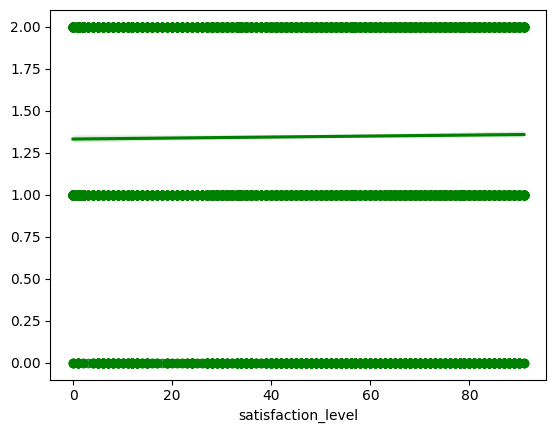

In [ ]:
#create a scatter plot with a linear regression line using the seaborn library
sns.regplot(x=df["satisfaction_level"],y=y,color="green")

<Axes: xlabel='last_evaluation'>

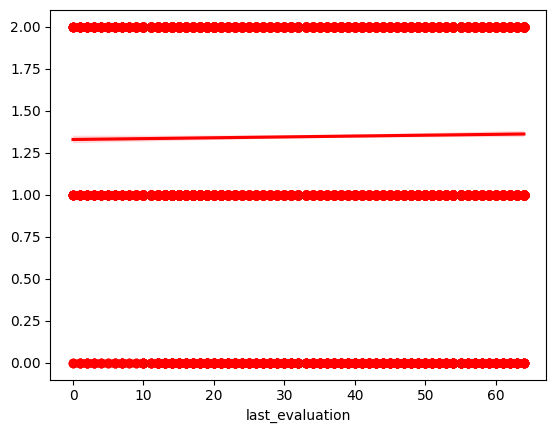

In [ ]:
sns.regplot(x=df["last_evaluation"],y=y,color="red")

<Axes: xlabel='number_project'>

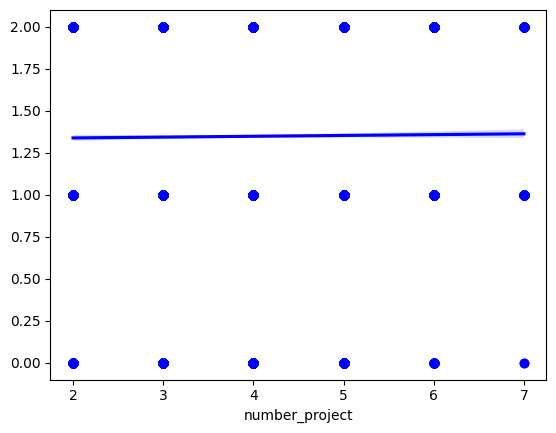

In [ ]:
sns.regplot(x=df["number_project"],y=y,color="blue")

<Axes: xlabel='average_montly_hours'>

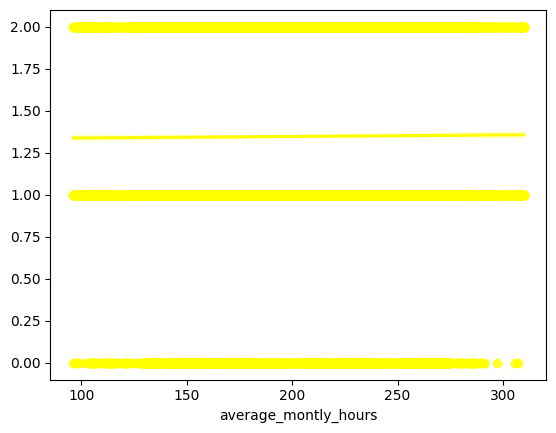

In [ ]:
sns.regplot(x=df["average_montly_hours"],y=y,color="yellow")

<Axes: xlabel='time_spend_company'>

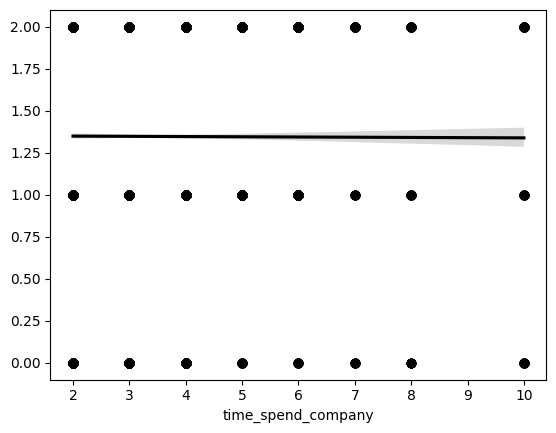

In [ ]:
sns.regplot(x=df["time_spend_company"],y=y,color="black")

<Axes: xlabel='Work_accident'>

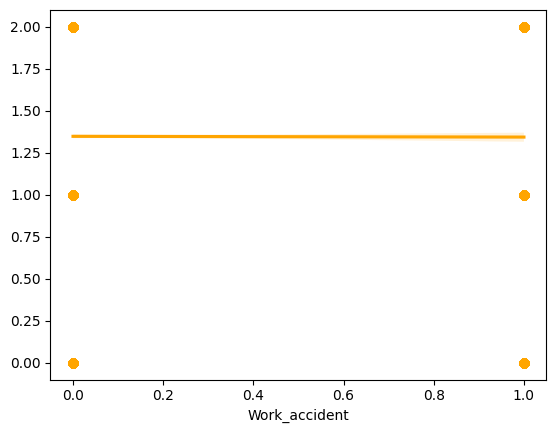

In [ ]:
sns.regplot(x=df["Work_accident"],y=y,color="orange")

<Axes: xlabel='left'>

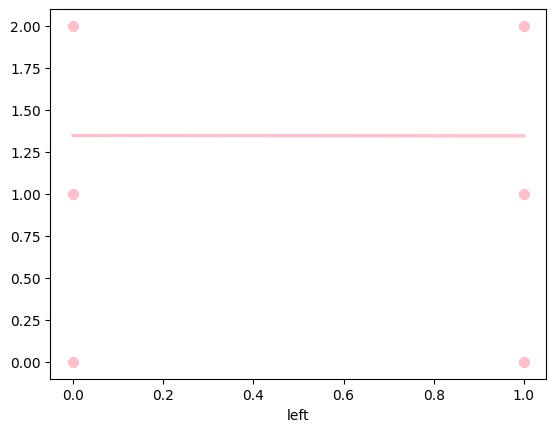

In [ ]:
sns.regplot(x=df["left"],y=y,color="pink")

<Axes: xlabel='promotion_last_5years'>

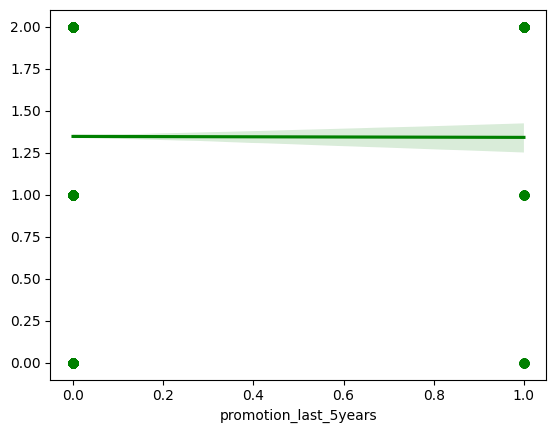

In [ ]:
sns.regplot(x=df["promotion_last_5years"],y=y,color="green")

<Axes: xlabel='Department'>

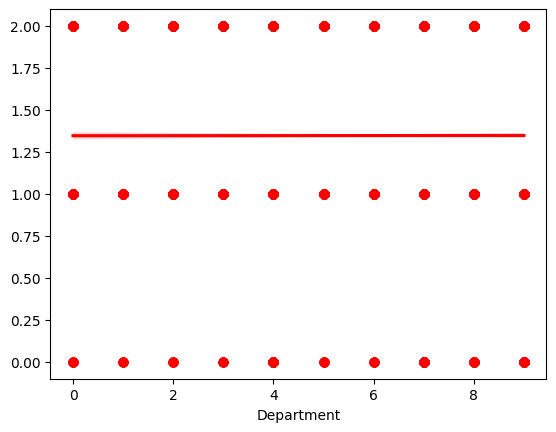

In [ ]:
sns.regplot(x=df["Department"],y=y,color="red")

<Axes: xlabel='salary'>

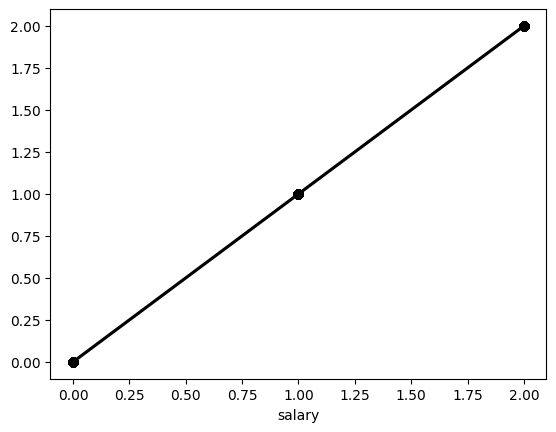

In [ ]:
sns.regplot(x=df["salary"],y=y,color="black")

In [ ]:
# 70% of data were train and 30% data where test the data
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.30,random_state=1)
x_train

array([[72, 24,  4, ...,  0,  0,  6],
       [49, 43,  3, ...,  0,  0,  7],
       [72, 47,  3, ...,  0,  0,  7],
       ...,
       [ 2, 42,  7, ...,  1,  0,  7],
       [74, 49,  4, ...,  1,  0,  4],
       [66, 57,  3, ...,  0,  0,  9]])

In [ ]:
x_train

array([[72, 24,  4, ...,  0,  0,  6],
       [49, 43,  3, ...,  0,  0,  7],
       [72, 47,  3, ...,  0,  0,  7],
       ...,
       [ 2, 42,  7, ...,  1,  0,  7],
       [74, 49,  4, ...,  1,  0,  4],
       [66, 57,  3, ...,  0,  0,  9]])

In [ ]:
model=LinearRegression()
model.fit(x_train,y_train)
y_pred=model.predict(x_test)
y_pred

array([1.30589061, 1.34937444, 1.33964655, ..., 1.35653066, 1.36370416,
       1.36745309])

In [ ]:
print(model.predict([[13,34,5,12,5,6,3,4,6]]))

[1.56250445]


In [ ]:
df1=pd.DataFrame({"actual value":y_test,"predicted value":y_pred})
df1

,actual value,predicted value
0,2,1.305891
1,2,1.349374
2,1,1.339647
3,1,1.344439
4,2,1.368167
...,...,...
4495,1,1.363573
4496,0,1.339654
4497,2,1.356531
4498,1,1.363704


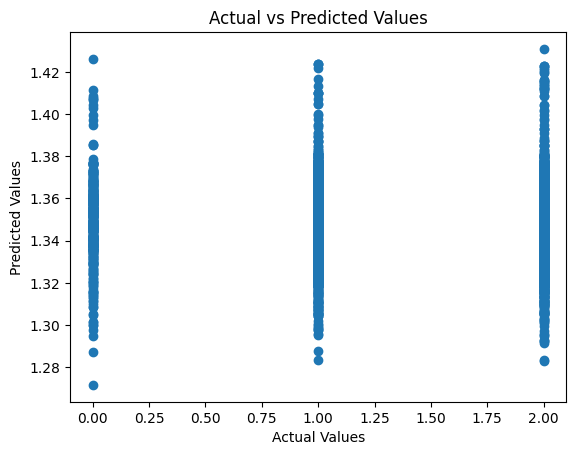

In [ ]:
plt.scatter(y_test,y_pred )
plt.title('Actual vs Predicted Values')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.show()

In [ ]:
#calculate the Mean Absolute Error between ypur actual value and predicted value.
print("mean absolute error",mean_absolute_error(y_test,y_pred))

mean absolute error 0.5595304114618961


In [ ]:
#calculate the Mean Absolute Percentage Error between actual value and predicted value.
print("mean absolute percentage error",mean_absolute_percentage_error(y_test,y_pred))

mean absolute percentage error 499638160563361.75


In [ ]:
#calculate the Mean Squared Error between actual value and predicted value.
print("mean squared error",mean_squared_error(y_test,y_pred))

mean squared error 0.3896752663881327


In [ ]:
#calculate the Root Mean Squared Error between actual value and predicted value.
from sklearn.metrics import root_mean_squared_error
x=mean_squared_error(y_test,y_pred)
print("root mean squared error",np.sqrt(x))

root mean squared error 0.624239750727341


In [ ]:
# to display the coefficients of the trained linear regression model.
print("slope is",model.coef_)

slope is [ 4.47173424e-04  1.71113178e-04  8.45679973e-03 -1.77795435e-05
 -6.07861233e-03 -3.04598208e-03  1.68889698e-02  4.95092433e-02
 -9.50109581e-06]
